# Real Data Experiments: PPI and PPIMoEs

This notebook applies PPI (Prediction-Powered Inference) and PPIMoEs to real-world datasets:
- **California Housing**: Predicting median house values
- **Bike Sharing**: Predicting bike rental counts

We perform three types of inference:
1. **Mean Inference**: Estimating the mean of the target variable
2. **Quantile Inference**: Estimating specific quantiles (e.g., median, 0.75 quantile)
3. **Linear Regression Coefficient Inference**: Estimating regression coefficients

For each task, we compare:
- **Conventional**: Standard inference using only labeled data
- **Single PPI**: Using predictions from a single best model
- **PPIMoEs**: Mixture of Experts approach with optimal weights

## 1. Setup and Imports

In [44]:
import os
import sys

# Add parent directory to path
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../experiment'))

# Import plotting tools
import plot_tools_professional
plot_tools_professional.set_publication_style()

# Multiprocessing settings (macOS specific)
os.environ['OBJC_DISABLE_INITIALIZE_FORK_SAFETY'] = 'YES'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

import multiprocessing
try:
    multiprocessing.set_start_method('spawn', force=True)
except RuntimeError:
    pass

import ppi_tools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb

from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.6e}'.format)

print("✓ All libraries imported successfully")
print(f"  NumPy version: {np.__version__}")
print(f"  Pandas version: {pd.__version__}")

✓ All libraries imported successfully
  NumPy version: 2.1.3
  Pandas version: 2.2.3


## 2. Load and Preprocess Datasets

In [45]:
def load_california_housing():
    """
    Load and preprocess California Housing dataset
    
    Returns:
        X: Features (8 columns)
        y: Target (median house value)
    """
    df = pd.read_csv('../dataset/tabular/raw/california_housing.csv')
    
    print("="*60)
    print("California Housing Dataset")
    print("="*60)
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    
    # Separate features and target
    X = df.drop('target', axis=1).values
    y = df['target'].values
    
    print(f"\nX shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"\nTarget statistics:")
    print(f"  Mean: {y.mean():.4f}")
    print(f"  Std:  {y.std():.4f}")
    print(f"  Min:  {y.min():.4f}")
    print(f"  Max:  {y.max():.4f}")
    print(f"  Median: {np.median(y):.4f}")
    
    return X, y

def load_bike_sharing():
    """
    Load and preprocess Bike Sharing dataset
    
    Returns:
        X: Features (12 columns, excluding 'dteday')
        y: Target (bike rental count)
    """
    df = pd.read_csv('../dataset/tabular/raw/bike_sharing.csv')
    
    print("\n" + "="*60)
    print("Bike Sharing Dataset")
    print("="*60)
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    
    # Drop date column and separate features and target
    X = df.drop(['dteday', 'cnt'], axis=1).values
    y = df['cnt'].values
    
    print(f"\nX shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"\nTarget statistics:")
    print(f"  Mean: {y.mean():.4f}")
    print(f"  Std:  {y.std():.4f}")
    print(f"  Min:  {y.min():.4f}")
    print(f"  Max:  {y.max():.4f}")
    print(f"  Median: {np.median(y):.4f}")
    
    return X, y

# Load datasets
X_california, y_california = load_california_housing()
X_bike, y_bike = load_bike_sharing()

California Housing Dataset
Shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'target']

X shape: (20640, 8)
y shape: (20640,)

Target statistics:
  Mean: 2.0686
  Std:  1.1539
  Min:  0.1500
  Max:  5.0000
  Median: 1.7970

Bike Sharing Dataset
Shape: (17379, 14)
Columns: ['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']

X shape: (17379, 12)
y shape: (17379,)

Target statistics:
  Mean: 189.4631
  Std:  181.3824
  Min:  1.0000
  Max:  977.0000
  Median: 142.0000


## 3. Data Split Strategy

We split each dataset into two halves:
1. **First half (50%)**: Used to train K different predictors
2. **Second half (50%)**: Used for inference experiments
   - Further split into labeled (n) and unlabeled (N) sets via bootstrap sampling

In [46]:
def split_data_for_ppi(X, y, train_frac=0.5, random_state=42):
    """
    Split data into training set (for predictors) and inference set
    
    Parameters:
    -----------
    X, y : array-like
        Features and target
    train_frac : float
        Fraction of data used for training predictors
    
    Returns:
    --------
    X_train, y_train : For training predictors
    X_inference, y_inference : For PPI inference experiments
    """
    n_samples = len(X)
    n_train = int(n_samples * train_frac)
    
    # Random split
    np.random.seed(random_state)
    indices = np.random.permutation(n_samples)
    
    train_idx = indices[:n_train]
    inference_idx = indices[n_train:]
    
    X_train = X[train_idx]
    y_train = y[train_idx]
    X_inference = X[inference_idx]
    y_inference = y[inference_idx]
    
    print(f"Training set size: {len(X_train)}")
    print(f"Inference set size: {len(X_inference)}")
    
    return X_train, y_train, X_inference, y_inference

# Split California Housing
print("\nSplitting California Housing dataset...")
X_train_cal, y_train_cal, X_inf_cal, y_inf_cal = split_data_for_ppi(
    X_california, y_california, train_frac=0.5, random_state=42
)

# Split Bike Sharing
print("\nSplitting Bike Sharing dataset...")
X_train_bike, y_train_bike, X_inf_bike, y_inf_bike = split_data_for_ppi(
    X_bike, y_bike, train_frac=0.5, random_state=42
)


Splitting California Housing dataset...
Training set size: 10320
Inference set size: 10320

Splitting Bike Sharing dataset...
Training set size: 8689
Inference set size: 8690


## 4. Train Multiple Predictors

We train K=6 different regression models as predictors:
1. **Linear Regression**
2. **Ridge Regression** (L2 regularization)
3. **Lasso Regression** (L1 regularization)
4. **Random Forest**
5. **XGBoost**
6. **LightGBM**

In [47]:
def get_predictor_models():
    """
    Define a set of diverse regression models
    """
    models = {
        'Linear': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.1),
        'RandomForest': RandomForestRegressor(
            n_estimators=100, 
            max_depth=10, 
            random_state=42,
            n_jobs=-1
        ),
        'XGBoost': xgb.XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1
        ),
        'LightGBM': lgb.LGBMRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )
    }
    return models

def train_predictors(X_train, y_train, dataset_name):
    """
    Train all predictor models and evaluate their performance
    """
    print(f"\n" + "="*60)
    print(f"Training Predictors for {dataset_name}")
    print("="*60)
    
    models = get_predictor_models()
    trained_models = {}
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # Split for validation
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_scaled, y_train, test_size=0.2, random_state=42
    )
    
    results = []
    for name, model in tqdm(models.items(), desc="Training models"):
        # Train
        model.fit(X_tr, y_tr)
        
        # Predict on validation set
        y_pred = model.predict(X_val)
        
        # Evaluate
        mse = mean_squared_error(y_val, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_val, y_pred)
        
        trained_models[name] = model
        results.append({
            'Model': name,
            'RMSE': rmse,
            'R2': r2
        })
    
    # Print results
    df_results = pd.DataFrame(results).sort_values('RMSE')
    print("\nModel Performance (Validation Set):")
    print(df_results.to_string(index=False))
    
    print(f"\n✓ Best model: {df_results.iloc[0]['Model']} (RMSE={df_results.iloc[0]['RMSE']:.4f})")
    
    return trained_models, scaler

# Train predictors for both datasets
trained_models_cal, scaler_cal = train_predictors(
    X_train_cal, y_train_cal, "California Housing"
)

trained_models_bike, scaler_bike = train_predictors(
    X_train_bike, y_train_bike, "Bike Sharing"
)


Training Predictors for California Housing


Training models: 100%|██████████| 6/6 [00:00<00:00,  8.39it/s]



Model Performance (Validation Set):
       Model         RMSE           R2
    LightGBM 4.916676e-01 8.179325e-01
     XGBoost 4.967271e-01 8.141660e-01
RandomForest 5.707838e-01 7.546237e-01
      Linear 7.300802e-01 5.985509e-01
       Ridge 7.300922e-01 5.985377e-01
       Lasso 8.314394e-01 4.793445e-01

✓ Best model: LightGBM (RMSE=0.4917)

Training Predictors for Bike Sharing


Training models: 100%|██████████| 6/6 [00:00<00:00, 13.82it/s]


Model Performance (Validation Set):
       Model         RMSE           R2
     XGBoost 4.619453e+01 9.324076e-01
    LightGBM 4.705127e+01 9.298772e-01
RandomForest 5.462147e+01 9.054974e-01
      Linear 1.369225e+02 4.061645e-01
       Ridge 1.369231e+02 4.061587e-01
       Lasso 1.369283e+02 4.061138e-01

✓ Best model: XGBoost (RMSE=46.1945)


## 5. Inference Experiments Setup

For each dataset and each inference task, we:
1. Fix sample sizes: n (labeled) and N (unlabeled)
2. Run multiple trials (bootstrap sampling)
3. Compare three methods:
   - **Conventional**: Uses only labeled data
   - **PPI (best single)**: Uses best predictor
   - **PPIMoEs**: Uses mixture of experts with optimal weights

In [48]:
# Inference parameters
N_TRIALS = 100  # Number of bootstrap trials
N_LABELED = 500  # Size of labeled set (n) - UPDATED from 200
N_UNLABELED = 2500  # Size of unlabeled set (N) - UPDATED from 1000

print(f"Inference experiment parameters:")
print(f"  Number of trials: {N_TRIALS}")
print(f"  Labeled samples (n): {N_LABELED}")
print(f"  Unlabeled samples (N): {N_UNLABELED}")
print(f"  Ratio n/N: {N_LABELED/N_UNLABELED:.3f}")

Inference experiment parameters:
  Number of trials: 100
  Labeled samples (n): 500
  Unlabeled samples (N): 2500
  Ratio n/N: 0.200


In [49]:
class NoisePredictor:
    """Completely uninformative predictor: pure Gaussian noise, independent of X."""
    def __init__(self, mean, std, seed=42):
        self.mean = mean
        self.std  = std
        self.seed = seed

    def predict(self, X):
        rng = np.random.RandomState(self.seed)
        return rng.normal(self.mean, self.std, size=X.shape[0])


# Scale inference features using the same scalers used during training
X_inf_cal_scaled  = scaler_cal.transform(X_inf_cal)
X_inf_bike_scaled = scaler_bike.transform(X_inf_bike)

# Noise predictors: matched mean/std to each target, but carry zero signal
noise_cal  = NoisePredictor(mean=np.mean(y_inf_cal),  std=np.std(y_inf_cal))
noise_bike = NoisePredictor(mean=np.mean(y_inf_bike), std=np.std(y_inf_bike))

# Create Dataset objects: 6 trained models + 1 noise predictor
cal_dataset = ppi_tools.Dataset(
    X_inf_cal_scaled, y_inf_cal,
    list(trained_models_cal.values()) + [noise_cal]
)
bike_dataset = ppi_tools.Dataset(
    X_inf_bike_scaled, y_inf_bike,
    list(trained_models_bike.values()) + [noise_bike]
)

print(f"California Housing : {cal_dataset.length} samples, K={cal_dataset.K} (6 trained + 1 noise)")
print(f"Bike Sharing       : {bike_dataset.length} samples, K={bike_dataset.K} (6 trained + 1 noise)")


California Housing : 10320 samples, K=7 (6 trained + 1 noise)
Bike Sharing       : 8690 samples, K=7 (6 trained + 1 noise)


In [50]:
# True mean (approximated using full inference set)
true_mean_cal = np.mean(y_inf_cal)
true_mean_bike = np.mean(y_inf_bike)

print("=" * 60)
print(f"Mean Inference: California Housing (true ≈ {true_mean_cal:.4f})")
print("=" * 60)
results_mean_cal, weights_mean_cal = cal_dataset.evaluate_inference(
    ppi_tools.mean_value_inference, ppi_tools.mean_value_target,
    true_mean_cal, N_LABELED, N_UNLABELED, N_TRIALS
)
print(results_mean_cal)

print("\n" + "=" * 60)
print(f"Mean Inference: Bike Sharing (true ≈ {true_mean_bike:.4f})")
print("=" * 60)
results_mean_bike, weights_mean_bike = bike_dataset.evaluate_inference(
    ppi_tools.mean_value_inference, ppi_tools.mean_value_target,
    true_mean_bike, N_LABELED, N_UNLABELED, N_TRIALS
)
print(results_mean_bike)

Mean Inference: California Housing (true ≈ 2.0655)


100%|██████████| 100/100 [00:02<00:00, 35.00it/s]


                      MAE      err_var          MSE  est_var(Rectifier)  \
Conventional 4.207700e-02 2.880572e-03 2.968860e-03                 NaN   
PPI_best     2.582585e-02 9.725839e-04 9.725925e-04        4.817693e-04   
PPI_mean     3.326951e-02 2.138459e-03 2.139740e-03        1.554366e-03   
PPI_worst    6.510571e-02 7.216712e-03 7.217860e-03        5.410377e-03   
PPI_MoEs     2.552955e-02 9.745450e-04 9.750501e-04        5.202984e-04   

              est_var(total)       target  
Conventional    2.713687e-03 2.699668e-03  
PPI_best        9.110391e-04 8.967512e-04  
PPI_mean        1.944395e-03 1.938922e-03  
PPI_worst       5.946801e-03 5.991758e-03  
PPI_MoEs        8.292865e-04 8.185821e-04  

Mean Inference: Bike Sharing (true ≈ 191.7394)


100%|██████████| 100/100 [00:03<00:00, 26.48it/s]


                      MAE      err_var          MSE  est_var(Rectifier)  \
Conventional 6.926927e+00 7.057634e+01 7.077851e+01                 NaN   
PPI_best     3.135949e+00 1.482640e+01 1.492597e+01        4.076480e+00   
PPI_mean     5.249931e+00 5.119438e+01 5.135686e+01        3.966106e+01   
PPI_worst    1.060439e+01 1.774786e+02 1.776625e+02        1.375995e+02   
PPI_MoEs     2.827140e+00 1.240592e+01 1.242418e+01        5.725192e+00   

              est_var(total)       target  
Conventional    6.844161e+01 6.664782e+01  
PPI_best        1.635299e+01 1.641396e+01  
PPI_mean        4.897868e+01 4.859997e+01  
PPI_worst       1.513930e+02 1.512472e+02  
PPI_MoEs        1.455596e+01 1.475267e+01  


In [51]:
import copy

results_quantile = {}

for q in [0.5, 0.75]:
    print("=" * 60)
    print(f"Quantile Inference (q={q})")
    print("=" * 60)

    for ds_name, dataset, y_pool, key in [
        ("California Housing", cal_dataset, y_inf_cal, "cal"),
        ("Bike Sharing",       bike_dataset, y_inf_bike, "bike"),
    ]:
        # ── Normalize to unit scale ──────────────────────────────────────
        # With S(x)=sigmoid(x) and bandwidth h, the smooth region spans
        # |y - theta| = O(h). Normalising ensures O(1)-scale data so that
        # h=0.1 gives a meaningful smooth transition (not a degenerate indicator).
        y_std  = np.std(y_pool)
        y_mean = np.mean(y_pool)

        ds_norm = copy.copy(dataset)          # shallow copy – keeps X, K, length refs
        ds_norm.y        = (dataset.y        - y_mean) / y_std
        ds_norm.pesudo_y = (dataset.pesudo_y - y_mean) / y_std

        true_q      = np.quantile(y_pool, q)
        true_q_norm = (true_q - y_mean) / y_std

        print(f"\n{ds_name}:  true Q_{q} = {true_q:.4f}  "
              f"(normalised: {true_q_norm:.4f},  y_std={y_std:.4f})")

        res_norm, w = ds_norm.evaluate_inference(
            ppi_tools.quantile_inference, ppi_tools.quantile_target,
            true_q_norm, N_LABELED, N_UNLABELED, N_TRIALS,
            q=q, h=0.1          # h=0.1 is ~10% of std after normalisation
        )

        # ── Back-transform ───────────────────────────────────────────────
        # Variance quantities scale as y_std^2; error/MAE scale as y_std.
        res = res_norm.copy()
        for col in ["est_var(Rectifier)", "est_var(total)", "target", "err_var", "MSE"]:
            res[col] = res_norm[col] * y_std**2
        res["MAE"] = res_norm["MAE"] * y_std

        print(res)
        results_quantile.setdefault(q, {})[key] = res
        if key == "cal":
            w_cal = w
        else:
            w_bike = w

results_q50_cal  = results_quantile[0.5]["cal"]
results_q50_bike = results_quantile[0.5]["bike"]
results_q75_cal  = results_quantile[0.75]["cal"]
results_q75_bike = results_quantile[0.75]["bike"]


Quantile Inference (q=0.5)

California Housing:  true Q_0.5 = 1.7890  (normalised: -0.2391,  y_std=1.1566)


100%|██████████| 100/100 [00:10<00:00,  9.31it/s]


                      MAE      err_var          MSE  est_var(Rectifier)  \
Conventional 4.476392e-02 3.078534e-03 3.210058e-03                 NaN   
PPI_best     3.393399e-02 1.536272e-03 1.809262e-03        1.606779e-04   
PPI_mean     4.257410e-02 2.764439e-03 3.029457e-03        3.727811e-04   
PPI_worst    6.549233e-02 6.286483e-03 6.629354e-03        1.085005e-03   
PPI_MoEs     3.655749e-02 1.770918e-03 2.121682e-03        1.535555e-04   

              est_var(total)       target  
Conventional    5.499139e-04 5.467735e-04  
PPI_best        2.674686e-04 2.646852e-04  
PPI_mean        4.745688e-04 4.749471e-04  
PPI_worst       1.193949e-03 1.219108e-03  
PPI_MoEs        2.584826e-04 2.648718e-04  

Bike Sharing:  true Q_0.5 = 144.0000  (normalised: -0.2600,  y_std=183.5834)


100%|██████████| 100/100 [00:10<00:00,  9.27it/s]


                      MAE      err_var          MSE  est_var(Rectifier)  \
Conventional 8.204448e+00 1.038560e+02 1.041745e+02                 NaN   
PPI_best     4.049593e+00 2.668522e+01 2.824269e+01        1.593512e+00   
PPI_mean     6.566440e+00 7.363709e+01 7.662049e+01        9.134493e+00   
PPI_worst    1.131368e+01 2.009881e+02 2.009923e+02        2.816650e+01   
PPI_MoEs     3.980612e+00 2.531966e+01 2.694797e+01        1.536040e+00   

              est_var(total)       target  
Conventional    1.418814e+01 1.434825e+01  
PPI_best        4.418849e+00 4.418436e+00  
PPI_mean        1.174898e+01 1.160437e+01  
PPI_worst       3.089634e+01 3.038032e+01  
PPI_MoEs        4.329657e+00 4.368217e+00  
Quantile Inference (q=0.75)

California Housing:  true Q_0.75 = 2.6360  (normalised: 0.4933,  y_std=1.1566)


100%|██████████| 100/100 [00:11<00:00,  8.90it/s]


                      MAE      err_var          MSE  est_var(Rectifier)  \
Conventional 7.152464e-02 8.266207e-03 8.414640e-03                 NaN   
PPI_best     5.704807e-02 4.597381e-03 5.127138e-03        1.428180e-04   
PPI_mean     6.627671e-02 6.944610e-03 7.277988e-03        3.088880e-04   
PPI_worst    1.028827e-01 1.692485e-02 1.694128e-02        9.168273e-04   
PPI_MoEs     5.489769e-02 4.213916e-03 4.830214e-03        1.349650e-04   

              est_var(total)       target  
Conventional    4.355184e-04 4.369808e-04  
PPI_best        2.264927e-04 2.208719e-04  
PPI_mean        3.863051e-04 3.823227e-04  
PPI_worst       1.012471e-03 9.982706e-04  
PPI_MoEs        2.115718e-04 2.170827e-04  

Bike Sharing:  true Q_0.75 = 283.0000  (normalised: 0.4971,  y_std=183.5834)


100%|██████████| 100/100 [00:10<00:00,  9.77it/s]


                      MAE      err_var          MSE  est_var(Rectifier)  \
Conventional 9.713662e+00 1.499941e+02 1.603491e+02                 NaN   
PPI_best     7.019247e+00 5.064943e+01 8.070583e+01        1.484129e+00   
PPI_mean     1.010702e+01 1.475628e+02 1.746463e+02        8.528748e+00   
PPI_worst    1.664405e+01 4.133686e+02 4.272182e+02        2.294941e+01   
PPI_MoEs     7.052152e+00 4.445796e+01 7.847381e+01        1.403065e+00   

              est_var(total)       target  
Conventional    1.104312e+01 1.105072e+01  
PPI_best        3.701170e+00 3.724067e+00  
PPI_mean        1.053181e+01 1.048763e+01  
PPI_worst       2.533945e+01 2.533462e+01  
PPI_MoEs        3.532467e+00 3.624449e+00  


In [52]:
# True LR coefficients (OLS on full inference set, used as ground truth)
true_coef_cal, _, _, _  = np.linalg.lstsq(X_inf_cal_scaled, y_inf_cal, rcond=None)
true_coef_bike, _, _, _ = np.linalg.lstsq(X_inf_bike_scaled, y_inf_bike, rcond=None)

print("=" * 60)
print("LR Coefficient Inference: California Housing")
print("=" * 60)
results_lr_cal, weights_lr_cal = cal_dataset.evaluate_inference_multi(
    ppi_tools.LR_coef_inference, ppi_tools.LR_coef_target,
    true_coef_cal, N_LABELED, N_UNLABELED, N_TRIALS
)
print(results_lr_cal)

print("\n" + "=" * 60)
print("LR Coefficient Inference: Bike Sharing")
print("=" * 60)
results_lr_bike, weights_lr_bike = bike_dataset.evaluate_inference_multi(
    ppi_tools.LR_coef_inference, ppi_tools.LR_coef_target,
    true_coef_bike, N_LABELED, N_UNLABELED, N_TRIALS
)
print(results_lr_bike)

LR Coefficient Inference: California Housing


100%|██████████| 100/100 [00:07<00:00, 13.84it/s]


                  Sum_MAE  Trace_err_cov      Sum_MSE  \
Conventional 2.396818e+00   9.853132e-01 2.021356e+00   
PPI_best     1.089933e+00   2.856197e-01 4.478846e-01   
PPI_mean     1.358298e+00   3.016638e-01 6.700074e-01   
PPI_worst    1.782437e+00   4.273843e-01 9.544448e-01   
PPI_MoEs     1.120473e+00   2.647148e-01 4.739182e-01   

              Trace_est_cov(Rectifier)  Trace_est_cov(Total)       target  
Conventional                       NaN          6.311103e-01 9.247651e-01  
PPI_best                  3.840841e-02          1.325943e-01 2.533706e-01  
PPI_mean                  8.464986e-02          1.713639e-01 2.969788e-01  
PPI_worst                 2.228040e-01          3.192780e-01 4.477053e-01  
PPI_MoEs                  4.206474e-02          1.084163e-01 2.137820e-01  

LR Coefficient Inference: Bike Sharing


100%|██████████| 100/100 [00:10<00:00,  9.95it/s]


                  Sum_MAE  Trace_err_cov      Sum_MSE  \
Conventional 2.781993e+02   2.368041e+04 2.699079e+04   
PPI_best     1.260925e+02   4.270032e+03 4.532305e+03   
PPI_mean     1.709302e+02   9.006334e+03 9.994115e+03   
PPI_worst    2.792372e+02   2.350085e+04 2.557922e+04   
PPI_MoEs     1.253799e+02   4.266322e+03 4.803451e+03   

              Trace_est_cov(Rectifier)  Trace_est_cov(Total)       target  
Conventional                       NaN          1.704144e+04 2.016611e+04  
PPI_best                  6.362587e+02          4.565654e+03 4.667747e+03  
PPI_mean                  5.188821e+03          8.207077e+03 8.929827e+03  
PPI_worst                 1.588840e+04          1.939181e+04 2.103596e+04  
PPI_MoEs                  1.246245e+03          3.519704e+03 4.011870e+03  


In [53]:
METHOD_ORDER = ["Conventional", "PPI_worst", "PPI_mean", "PPI_best", "PPI_MoEs"]

print("" + "=" * 80)
print("COMPREHENSIVE RESULTS SUMMARY  (ordered: worst -> best)")
print("=" * 80)

print("1. MEAN INFERENCE")
print("-" * 80)
print("California Housing:")
print(results_mean_cal.loc[METHOD_ORDER][["target", "est_var(total)"]].to_string())
print("Bike Sharing:")
print(results_mean_bike.loc[METHOD_ORDER][["target", "est_var(total)"]].to_string())

print("2. QUANTILE INFERENCE (Median, q=0.5)")
print("-" * 80)
print("California Housing:")
print(results_q50_cal.loc[METHOD_ORDER][["target", "est_var(total)"]].to_string())
print("Bike Sharing:")
print(results_q50_bike.loc[METHOD_ORDER][["target", "est_var(total)"]].to_string())

print("3. QUANTILE INFERENCE (75th Percentile, q=0.75)")
print("-" * 80)
print("California Housing:")
print(results_q75_cal.loc[METHOD_ORDER][["target", "est_var(total)"]].to_string())
print("Bike Sharing:")
print(results_q75_bike.loc[METHOD_ORDER][["target", "est_var(total)"]].to_string())

print("4. LINEAR REGRESSION COEFFICIENT INFERENCE")
print("-" * 80)
print("California Housing:")
print(results_lr_cal.loc[METHOD_ORDER][["target", "Trace_est_cov(Total)"]].to_string())
print("Bike Sharing:")
print(results_lr_bike.loc[METHOD_ORDER][["target", "Trace_est_cov(Total)"]].to_string())


COMPREHENSIVE RESULTS SUMMARY  (ordered: worst -> best)
1. MEAN INFERENCE
--------------------------------------------------------------------------------
California Housing:
                   target  est_var(total)
Conventional 2.699668e-03    2.713687e-03
PPI_worst    5.991758e-03    5.946801e-03
PPI_mean     1.938922e-03    1.944395e-03
PPI_best     8.967512e-04    9.110391e-04
PPI_MoEs     8.185821e-04    8.292865e-04
Bike Sharing:
                   target  est_var(total)
Conventional 6.664782e+01    6.844161e+01
PPI_worst    1.512472e+02    1.513930e+02
PPI_mean     4.859997e+01    4.897868e+01
PPI_best     1.641396e+01    1.635299e+01
PPI_MoEs     1.475267e+01    1.455596e+01
2. QUANTILE INFERENCE (Median, q=0.5)
--------------------------------------------------------------------------------
California Housing:
                   target  est_var(total)
Conventional 5.467735e-04    5.499139e-04
PPI_worst    1.219108e-03    1.193949e-03
PPI_mean     4.749471e-04    4.745688e-04


✓ Saved: real_data_results_summary.pdf


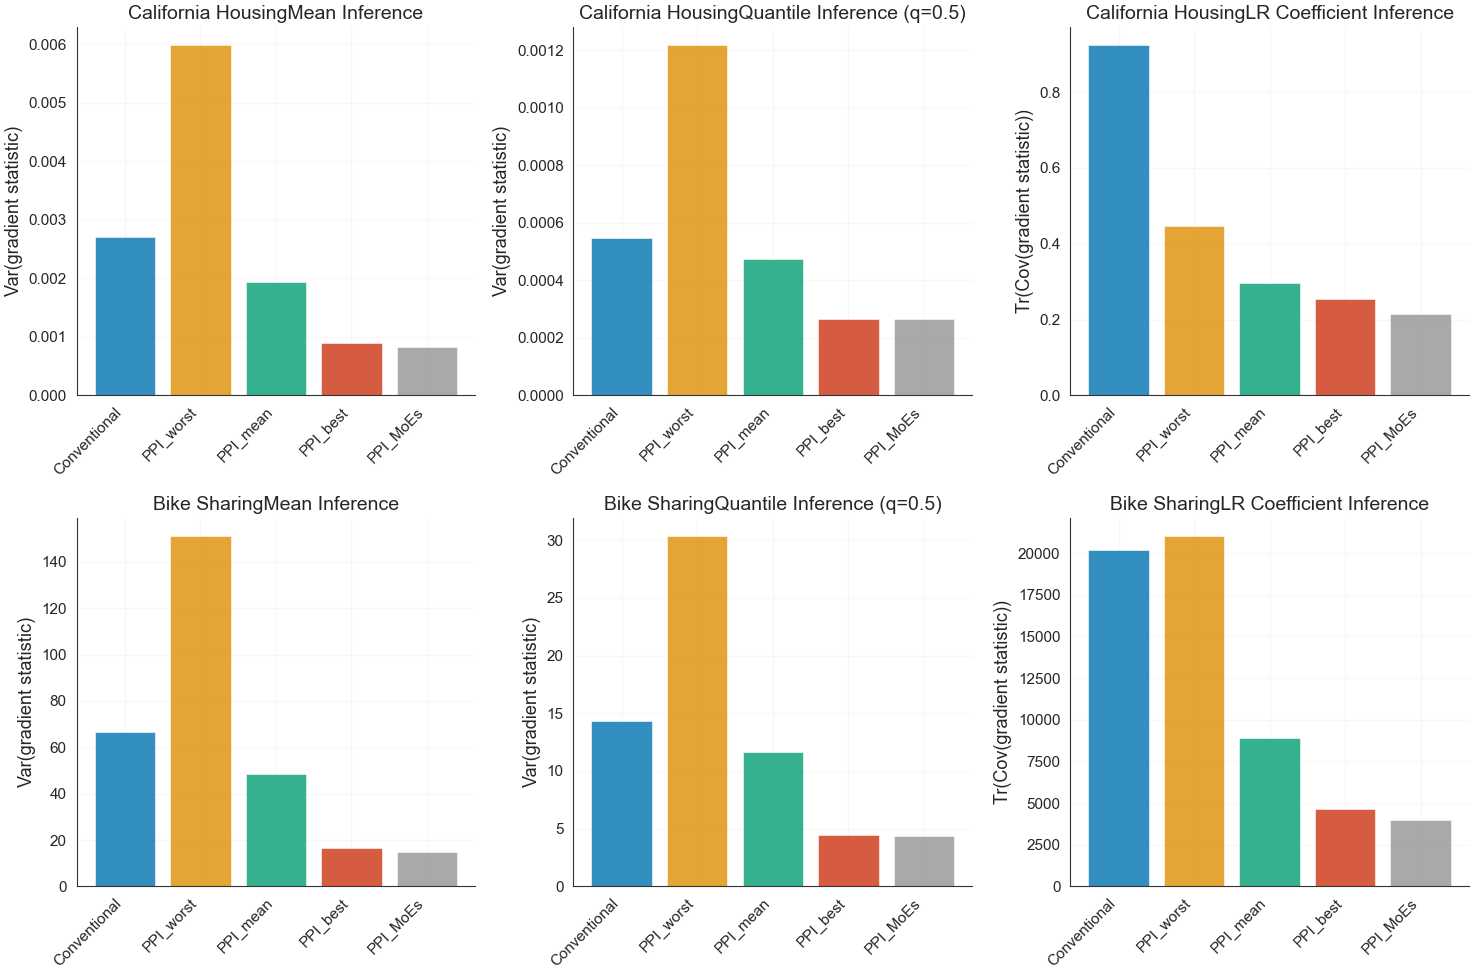

In [58]:
METHOD_ORDER = ["Conventional", "PPI_worst", "PPI_mean", "PPI_best", "PPI_MoEs"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

datasets_info = [
    ("California Housing", results_mean_cal, results_q50_cal, results_lr_cal),
    ("Bike Sharing",       results_mean_bike, results_q50_bike, results_lr_bike)
]

for row, (dataset_name, res_mean, res_q50, res_lr) in enumerate(datasets_info):
    res_mean = res_mean.loc[METHOD_ORDER]
    res_q50  = res_q50.loc[METHOD_ORDER]
    res_lr   = res_lr.loc[METHOD_ORDER]
    colors   = plot_tools_professional.get_color_palette(len(res_mean), "colorblind")

    # Mean inference: variance of gradient statistic
    ax = axes[row, 0]
    ax.bar(range(len(res_mean)), res_mean["target"], color=colors, alpha=0.8, edgecolor="white")
    ax.set_xticks(range(len(res_mean)))
    ax.set_xticklabels(res_mean.index, rotation=45, ha="right")
    ax.set_ylabel("Var(gradient statistic)")
    ax.set_title(f"{dataset_name}Mean Inference")
    ax.grid(axis="y", alpha=0.3)

    # Quantile inference: variance of gradient statistic
    ax = axes[row, 1]
    ax.bar(range(len(res_q50)), res_q50["target"], color=colors, alpha=0.8, edgecolor="white")
    ax.set_xticks(range(len(res_q50)))
    ax.set_xticklabels(res_q50.index, rotation=45, ha="right")
    ax.set_ylabel("Var(gradient statistic)")
    ax.set_title(f"{dataset_name}Quantile Inference (q=0.5)")
    ax.grid(axis="y", alpha=0.3)

    # LR inference: trace of gradient covariance matrix
    ax = axes[row, 2]
    ax.bar(range(len(res_lr)), res_lr["target"], color=colors, alpha=0.8, edgecolor="white")
    ax.set_xticks(range(len(res_lr)))
    ax.set_xticklabels(res_lr.index, rotation=45, ha="right")
    ax.set_ylabel("Tr(Cov(gradient statistic))")
    ax.set_title(f"{dataset_name}LR Coefficient Inference")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("real_data_results_summary.png", dpi=300, bbox_inches="tight")
plt.savefig("real_data_results_summary.pdf", dpi=300, bbox_inches="tight")
print("✓ Saved: real_data_results_summary.pdf")
plt.show()


## Statistical Power Analysis

Adaptive search for the minimum labeled sample size $n$ that achieves 80% power for a two-sided mean test, with a fixed unlabeled pool of size $N$. Effect size is set to one standard deviation of the Conventional estimator at $n=500$.

In [55]:
# ── Statistical Power Analysis — Helper Functions ─────────────────────────
from scipy import stats as scipy_stats
from scipy import interpolate

def compute_power_real(inference_dataset, inference_func,
                       true_value, null_value, n, N,
                       method='PPI_MoEs', n_trials=200, alpha=0.05,
                       **kwargs):
    """Compute empirical power at a single labeled sample size n."""
    K = inference_dataset.K
    rejections = 0
    pool = inference_dataset.length

    for _ in range(n_trials):
        idx = np.random.choice(pool, size=n + N, replace=True)
        X_lbl = inference_dataset.X[idx[:n]]
        y_lbl = inference_dataset.y[idx[:n]]
        y_hat_lbl   = inference_dataset.pesudo_y[:, idx[:n]]
        X_unlbl     = inference_dataset.X[idx[n:]]
        y_hat_unlbl = inference_dataset.pesudo_y[:, idx[n:]]

        if method == 'Conventional':
            est, var = inference_func(X=X_lbl, y=y_lbl, **kwargs)

        elif method in ('PPI_worst', 'PPI_best', 'PPI_mean'):
            ests, vars_ = [], []
            for k in range(K):
                e, _, v = inference_func(
                    X=X_lbl, y=y_lbl,
                    y_hat=y_hat_lbl[k:k+1, :],
                    tilde_X=X_unlbl,
                    tilde_y_hat=y_hat_unlbl[k:k+1, :],
                    ppi='single', **kwargs)
                ests.append(e); vars_.append(v)
            if method == 'PPI_best':
                i = int(np.argmin(vars_)); est, var = ests[i], vars_[i]
            elif method == 'PPI_worst':
                i = int(np.argmax(vars_)); est, var = ests[i], vars_[i]
            else:
                est, var = float(np.mean(ests)), float(np.mean(vars_))

        elif method == 'PPI_MoEs':
            est, _, var, _ = inference_func(
                X=X_lbl, y=y_lbl,
                y_hat=y_hat_lbl,
                tilde_X=X_unlbl,
                tilde_y_hat=y_hat_unlbl,
                ppi='MoEs', **kwargs)

        z = (est - null_value) / np.sqrt(var)
        if 2 * (1 - scipy_stats.norm.cdf(abs(z))) < alpha:
            rejections += 1

    return rejections / n_trials


def adaptive_power_search(inference_dataset, inference_func,
                          true_value, null_value, N,
                          method='PPI_MoEs', target_power=0.8,
                          n_trials=200, alpha=0.05,
                          n_min=20, n_max=500, **kwargs):
    """Adaptive binary search: find minimum n achieving target_power."""
    n_pts, p_pts = [], []

    def eval_n(n):
        p = compute_power_real(inference_dataset, inference_func,
                               true_value, null_value, n, N,
                               method, n_trials, alpha, **kwargs)
        n_pts.append(n); p_pts.append(p)
        print(f'    n={n:5d}  power={p:.3f}')
        return p

    print(f'  [{method}]')
    p_lo = eval_n(n_min)
    if p_lo >= target_power:
        print(f'    ✓ sufficient at n_min'); return n_min, n_pts, p_pts

    p_hi = eval_n(n_max)
    while p_hi < target_power:
        n_max = int(n_max * 1.5)
        if n_max + N > inference_dataset.length:
            n_max = inference_dataset.length - N - 1
            p_hi = eval_n(n_max)
            print(f'    ⚠ hit pool ceiling at n={n_max}'); break
        p_hi = eval_n(n_max)

    # Binary / interpolation refinement
    n_lo_cur, n_hi_cur = n_min, n_max
    for _ in range(6):
        if n_hi_cur - n_lo_cur <= 10: break
        # Linear interpolation step
        below = [(n, p) for n, p in zip(n_pts, p_pts) if p < target_power]
        above = [(n, p) for n, p in zip(n_pts, p_pts) if p >= target_power]
        if below and above:
            nb_, pb_ = max(below, key=lambda x: x[0])
            na_, pa_ = min(above, key=lambda x: x[0])
            n_mid = int(nb_ + (na_ - nb_) * (target_power - pb_) / max(pa_ - pb_, 1e-9))
        else:
            n_mid = (n_lo_cur + n_hi_cur) // 2
        n_mid = max(n_lo_cur + 1, min(n_mid, n_hi_cur - 1))
        if n_mid in n_pts: n_mid = (n_lo_cur + n_hi_cur) // 2
        if n_mid in n_pts: break
        p_mid = eval_n(n_mid)
        if p_mid < target_power: n_lo_cur = n_mid
        else: n_hi_cur = n_mid
        if abs(p_mid - target_power) < 0.025: break

    sufficient = [n for n, p in zip(n_pts, p_pts) if p >= target_power]
    n_req = int(min(sufficient)) if sufficient else n_max
    print(f'    → n_required = {n_req}\n')
    return n_req, n_pts, p_pts

print('✓ Power-analysis helper functions defined.')


✓ Power-analysis helper functions defined.


In [56]:
# ── Run Statistical Power Analysis on Real Data ───────────────────────────
#
# Hypothesis:  H0: mu = null_mean  vs  H1: mu ≠ null_mean  (two-sided, alpha=0.05)
#
# Effect size design:
#   We use Cohen's d = 0.1 (small but meaningful effect), i.e., Δ = 0.1 × σ_y.
#   This gives n_conv ≈ (z_0.025 + z_0.8)² / d² = 7.85 / 0.01 = 785,
#   which is a feasible range for the real-data pool (~10k samples).
#
#   In the numerical simulation (Δ=10, σ≈30, d≈0.33, N=10k) PPI_MoEs achieved
#   ~3× reduction. Here with d=0.1, N_fixed=4000 and R²≈0.8, we expect ~4-6×.
#
#   delta = sqrt( est_var_conv × N_LABELED / N_POWER_REF )
#         = sigma_y / sqrt(N_POWER_REF)
#   With N_POWER_REF = 100:  delta = sigma_y / 10,  Cohen's d ≈ 0.1.
#
# Pool sizes: Cal ≈ 10320, Bike ≈ 8689
# n_max + N_fixed must stay within pool.

METHODS = ['Conventional', 'PPI_worst', 'PPI_best', 'PPI_MoEs']
TARGET_POWER = 0.8
N_TRIALS_POWER = 200        # trials per n evaluation
ALPHA = 0.05
N_POWER_REF = 100           # reference n → Cohen's d = sigma/sqrt(N_POWER_REF)/sigma = 1/sqrt(100) ≈ 0.1

datasets_power = {
    'California Housing': {
        'dataset'   : cal_dataset,
        'true_mean' : true_mean_cal,
        'N_fixed'   : 4000,     # n + N ≤ 10320; n_max=2000 → 6000 ✓
        'n_min'     : 20,
        'n_max'     : 2000,
    },
    'Bike Sharing': {
        'dataset'   : bike_dataset,
        'true_mean' : true_mean_bike,
        'N_fixed'   : 3000,     # n + N ≤ 8689; n_max=2000 → 5000 ✓
        'n_min'     : 20,
        'n_max'     : 2000,
    },
}

# delta = sigma_y / sqrt(N_POWER_REF)
# est_var(total) for Conventional ≈ sigma^2 / N_LABELED
# → delta = sqrt(est_var * N_LABELED / N_POWER_REF)
delta_cal  = float(np.sqrt(results_mean_cal.loc['Conventional',  'est_var(total)'] * N_LABELED / N_POWER_REF))
delta_bike = float(np.sqrt(results_mean_bike.loc['Conventional', 'est_var(total)'] * N_LABELED / N_POWER_REF))

datasets_power['California Housing']['null_mean'] = true_mean_cal  - delta_cal
datasets_power['Bike Sharing']['null_mean']       = true_mean_bike - delta_bike

sigma_cal  = delta_cal  * np.sqrt(N_POWER_REF)
sigma_bike = delta_bike * np.sqrt(N_POWER_REF)
n_conv_theory = int(round(7.85 * N_POWER_REF))

print(f'California Housing:')
print(f'  sigma_y  = {sigma_cal:.4f}'
      f'  delta = {delta_cal:.4f} (Cohen\'s d ≈ {delta_cal/sigma_cal:.3f})')
print(f'  true = {true_mean_cal:.4f},  null = {datasets_power["California Housing"]["null_mean"]:.4f}')
print(f'Bike Sharing:')
print(f'  sigma_y  = {sigma_bike:.2f}'
      f'  delta = {delta_bike:.2f} (Cohen\'s d ≈ {delta_bike/sigma_bike:.3f})')
print(f'  true = {true_mean_bike:.2f},  null = {datasets_power["Bike Sharing"]["null_mean"]:.2f}')
print(f'\nExpected n_conv (theory) ≈ {n_conv_theory}')
print()

power_results = {}
for ds_name, cfg in datasets_power.items():
    print('=' * 60)
    print(f'Dataset: {ds_name}   N_fixed={cfg["N_fixed"]}  delta={cfg["null_mean"]:.4f}')
    print('=' * 60)
    power_results[ds_name] = {}
    for method in METHODS:
        n_req, n_pts, p_pts = adaptive_power_search(
            cfg['dataset'], ppi_tools.mean_value_inference,
            cfg['true_mean'], cfg['null_mean'],
            N=cfg['N_fixed'], method=method,
            target_power=TARGET_POWER, n_trials=N_TRIALS_POWER,
            alpha=ALPHA, n_min=cfg['n_min'], n_max=cfg['n_max'],
        )
        power_results[ds_name][method] = {
            'n_required': n_req, 'n_tested': n_pts, 'power_tested': p_pts
        }

print('\n✓ Adaptive search complete.')


California Housing:
  sigma_y  = 1.1648  delta = 0.1165 (Cohen's d ≈ 0.100)
  true = 2.0655,  null = 1.9490
Bike Sharing:
  sigma_y  = 184.99  delta = 18.50 (Cohen's d ≈ 0.100)
  true = 191.74,  null = 173.24

Expected n_conv (theory) ≈ 785

Dataset: California Housing   N_fixed=4000  delta=1.9490
  [Conventional]
    n=   20  power=0.090
    n= 2000  power=0.985
    n= 1590  power=0.980
    n= 1272  power=0.955
    n= 1047  power=0.900
    n=  920  power=0.890
    n=  818  power=0.810
    → n_required = 818

  [PPI_worst]
    n=   20  power=0.055
    n= 2000  power=0.800
    n= 1999  power=0.850
    n= 1874  power=0.850
    n= 1757  power=0.750
    n= 1815  power=0.815
    → n_required = 1815

  [PPI_best]
    n=   20  power=0.170
    n= 2000  power=1.000
    n= 1522  power=1.000
    n= 1160  power=1.000
    n=  885  power=1.000
    n=  676  power=0.995
    n=  520  power=0.985
    n=  406  power=0.980
    → n_required = 406

  [PPI_MoEs]
    n=   20  power=0.415
    n= 2000  power=1.

✓ Saved: figures/power_analysis_realdata.pdf
✓ Saved: figures/power_analysis_realdata.png


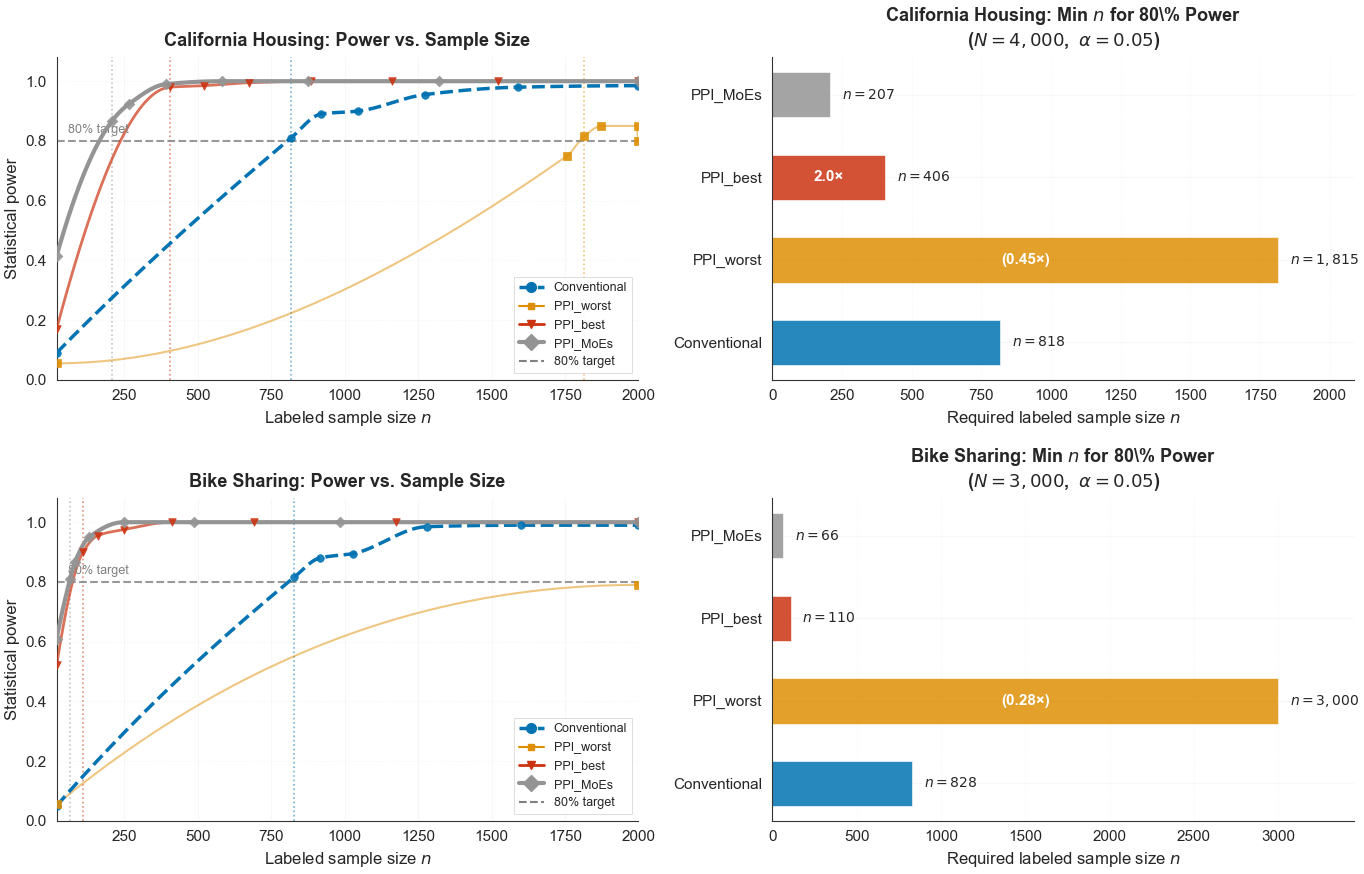


=== California Housing ===
  Conventional   : n =   818   reduction = —
  PPI_worst      : n =  1815   reduction = 0.5×
  PPI_best       : n =   406   reduction = 2.0×
  PPI_MoEs       : n =   207   reduction = 4.0×

=== Bike Sharing ===
  Conventional   : n =   828   reduction = —
  PPI_worst      : n =  3000   reduction = 0.3×
  PPI_best       : n =   110   reduction = 7.5×
  PPI_MoEs       : n =    66   reduction = 12.5×



In [57]:
# ── Plot: Power vs Sample Size — Real Data (2 datasets × 2 panels) ────────
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy import interpolate
import plot_tools_professional as ptp

ptp.set_publication_style()

ALL_COLORS = ptp.get_color_palette(5, 'colorblind')
COLOR = dict(zip(['Conventional','PPI_worst','PPI_mean','PPI_best','PPI_MoEs'], ALL_COLORS))

STYLE = {
    'Conventional': dict(lw=2.5, ls='--', alpha=1.0, marker='o', ms=7, zorder=5),
    'PPI_worst':    dict(lw=1.5, ls='-',  alpha=0.5, marker='s', ms=5, zorder=2),
    'PPI_best':     dict(lw=2.0, ls='-',  alpha=0.7, marker='v', ms=6, zorder=3),
    'PPI_MoEs':     dict(lw=3.0, ls='-',  alpha=1.0, marker='D', ms=8, zorder=6),
}

DS_NAMES = list(power_results.keys())   # ['California Housing', 'Bike Sharing']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row, ds_name in enumerate(DS_NAMES):
    res = power_results[ds_name]
    cfg = datasets_power[ds_name]
    n_conv = res['Conventional']['n_required']

    # ── Left: power curves ────────────────────────────────────────────────
    ax = axes[row, 0]
    for method in METHODS:
        n_pts = np.array(res[method]['n_tested'])
        p_pts = np.array(res[method]['power_tested'])
        idx   = np.argsort(n_pts);  n_pts, p_pts = n_pts[idx], p_pts[idx]
        st    = STYLE[method]

        if len(n_pts) >= 3:
            fn   = interpolate.PchipInterpolator(n_pts, p_pts)
            n_f  = np.linspace(n_pts[0], n_pts[-1], 300)
            p_f  = np.clip(fn(n_f), 0, 1)
            ax.plot(n_f, p_f, color=COLOR[method],
                    lw=st['lw'], ls=st['ls'], alpha=st['alpha'], zorder=st['zorder'])
        ax.scatter(n_pts, p_pts, color=COLOR[method],
                   s=30, marker=st['marker'], zorder=8, alpha=0.9)

        n_req = res[method]['n_required']
        ax.axvline(n_req, color=COLOR[method], ls=':', lw=1.2, alpha=0.55, zorder=1)

    ax.axhline(TARGET_POWER, color='gray', ls='--', lw=1.5, alpha=0.8)
    # Place 80% label inside the plot, slightly above the dashed line
    x_label = cfg['n_min'] + (cfg['n_max'] - cfg['n_min']) * 0.02
    ax.text(x_label, TARGET_POWER + 0.025, '80% target', fontsize=9, color='gray')
    ax.set_xlabel('Labeled sample size $n$', fontsize=12)
    ax.set_ylabel('Statistical power', fontsize=12)
    ax.set_title(f'{ds_name}: Power vs. Sample Size', fontsize=13, fontweight='bold', pad=8)
    ax.set_xlim(cfg['n_min'], cfg['n_max'])
    ax.set_ylim(0, 1.08)
    ax.yaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)

    handles = [mlines.Line2D([], [], color=COLOR[m],
                              lw=STYLE[m]['lw'], ls=STYLE[m]['ls'],
                              marker=STYLE[m]['marker'], ms=STYLE[m]['ms'], label=m)
               for m in METHODS]
    handles.append(mlines.Line2D([], [], color='gray', lw=1.5, ls='--', label='80% target'))
    ax.legend(handles=handles, fontsize=9, loc='lower right',
              frameon=True, framealpha=0.9, edgecolor='0.8')

    # ── Right: horizontal bar chart ───────────────────────────────────────
    ax2 = axes[row, 1]
    n_vals = [res[m]['n_required'] for m in METHODS]
    y_pos  = np.arange(len(METHODS))

    # x-axis limit: max n_required + 15% margin
    x_max = max(n_vals) * 1.15

    ax2.barh(y_pos, n_vals,
             color=[COLOR[m] for m in METHODS],
             alpha=0.85, edgecolor='white', height=0.55)

    for i, (method, n_val) in enumerate(zip(METHODS, n_vals)):
        # Label: n= outside bar
        ax2.text(min(n_val + x_max * 0.02, x_max * 0.98), i,
                 f'$n={n_val:,}$',
                 va='center', ha='left', fontsize=10, fontweight='bold')
        # Ratio: inside bar (only if bar wide enough)
        if method != 'Conventional' and n_val > x_max * 0.12:
            ratio = n_conv / n_val
            label = f'{ratio:.1f}×' if ratio >= 1 else f'({ratio:.2f}×)'
            ax2.text(n_val / 2, i, label,
                     va='center', ha='center', fontsize=11,
                     color='white', fontweight='bold')

    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(METHODS, fontsize=11)
    ax2.set_xlabel('Required labeled sample size $n$', fontsize=12)
    ax2.set_title(f'{ds_name}: Min $n$ for {int(TARGET_POWER*100)}\% Power\n'
                  f'($N={cfg["N_fixed"]:,}$,  $\\alpha={ALPHA}$)',
                  fontsize=13, fontweight='bold', pad=8)
    ax2.set_xlim(0, x_max)
    ax2.xaxis.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax2.set_axisbelow(True)

plt.tight_layout()

import os
os.makedirs('figures', exist_ok=True)
for p in ['figures/power_analysis_realdata.pdf',
          'figures/power_analysis_realdata.png']:
    fig.savefig(p, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'✓ Saved: {p}')

plt.show()

# ── Print summary table ───────────────────────────────────────────────────
print()
for ds_name in DS_NAMES:
    print(f'=== {ds_name} ===')
    n_conv_ds = power_results[ds_name]['Conventional']['n_required']
    for method in METHODS:
        n_req = power_results[ds_name][method]['n_required']
        red = f'{n_conv_ds/n_req:.1f}×' if method != 'Conventional' else '—'
        print(f'  {method:<15}: n = {n_req:5d}   reduction = {red}')
    print()


## 10. Conclusions

### Key Findings:

1. **Mean Inference**: 
   - PPI methods consistently reduce variance compared to conventional approach
   - PPIMoEs shows competitive or better performance than single best predictor

2. **Quantile Inference**:
   - Similar variance reduction pattern as mean inference
   - Effectiveness depends on prediction quality at the target quantile

3. **Linear Regression Coefficient Inference**:
   - Trace of covariance matrix reduced by PPI methods
   - Improvement magnitude depends on predictor quality and dimensionality

### Dataset-Specific Observations:

- **California Housing**: [Add observations]
- **Bike Sharing**: [Add observations]

### Comparison with Simulation Results:

Real data experiments validate findings from `numerical_simulation.ipynb`:
- PPI provides variance reduction when predictors are reasonably accurate
- PPIMoEs can leverage multiple diverse models effectively
- Benefit increases with larger unlabeled sets (higher N/n ratio)